In [1]:
## necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# packages for OLS
import statsmodels.api as sm
# packages for Lasso and Ridge
from sklearn.linear_model import Lasso, Ridge
# packages for cross validation
from sklearn.model_selection import train_test_split, cross_val_score
# packages for evaluation metrics


ModuleNotFoundError: No module named 'sklearn'

In [4]:
import pmdarima as pm

### Data importing and Cleaning

In [5]:
# read data
data1 = pd.read_excel("/Users/geoffpoint-du-jour/Downloads/Forecasting/Climate Data/Downscaled_MESSAGEix-GLOBIOM 2.0-M-R12-NGFS_data.xlsx")
loandata = pd.read_csv("BUSLOANS.CSV")
cpi = pd.read_csv("CPI.csv")
unemployment = pd.read_csv("UNEMPLOYMENT.csv")

In [6]:
data1.describe()

,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
count,174119.000000,17766.000000,17766.000000,17766.000000,17766.000000,173593.000000,17766.000000,17766.000000,17766.000000,17766.000000,...,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000
mean,95.236762,840.967060,866.092443,891.087843,917.006110,108.933840,969.639685,996.338306,1022.676059,1049.292877,...,3127.281510,3163.518732,3201.570250,3242.751005,3285.449618,3328.596394,3370.754859,3412.454024,3452.267658,3489.628947
std,2289.750694,7307.534944,7535.206910,7761.007686,7993.573881,2665.725873,8463.375885,8700.701152,8934.736738,9170.846646,...,27268.459557,27585.451116,27917.904010,28276.030559,28646.450299,29020.727551,29387.234932,29750.197432,30098.085245,30426.271405
min,-943.333400,-2.092654,-4.364267,-6.741271,-8.660476,-943.333400,-12.707780,-14.835680,-16.965630,-19.100350,...,-81.798450,-82.253550,-82.752540,-83.052440,-83.340140,-83.636070,-83.953930,-84.303440,-84.606930,-84.979890
25%,0.000000,-0.579394,-1.145731,-1.713888,-2.196124,0.000000,-3.080627,-3.466194,-3.909014,-4.286945,...,-9.865396,-9.981096,-10.022375,-9.967483,-9.885205,-9.745334,-9.670343,-9.572050,-9.547108,-9.553268
50%,0.006200,3.551642,4.440057,5.378792,5.805345,0.009100,6.611908,7.486106,8.135852,8.551282,...,27.193900,27.320940,27.527850,27.673905,27.654960,27.789595,27.983630,28.079895,28.304590,28.493520
75%,0.353400,164.802850,169.163125,163.364550,168.849250,0.442900,185.604725,192.341550,199.239550,209.005275,...,821.159900,828.797350,841.240500,855.047225,864.447725,875.365525,882.492400,892.358800,899.330625,903.313425
max,114983.700000,119390.500000,123735.100000,128030.200000,132300.000000,136556.300000,141062.500000,145617.200000,150189.600000,154795.100000,...,518460.000000,525323.000000,532328.200000,539488.600000,546723.000000,553987.700000,561212.700000,568369.900000,575400.300000,582255.800000


In [7]:
loandata.tail() # data is 1947 to present

,observation_date,BUSLOANS
944,2025-09-01,2693.7380
945,2025-10-01,2692.3125
946,2025-11-01,2698.5199
947,2025-12-01,2709.2908
948,2026-01-01,2743.0472


In [8]:
# take a look into unemploymenbt
unemployment.head()

,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [9]:
# do a regression with loandata as the dependent variable and unemployment as the independent variable
# merge the two datasets on the date column
# convert date columns to datetime
loandata['Date'] = pd.to_datetime(loandata['observation_date'])
unemployment['Date'] = pd.to_datetime(unemployment['observation_date'])
# merge datasets
merged_data = pd.merge(loandata, unemployment, on='observation_date', how='inner')
# check the merged data
merged_data.head()


,observation_date,BUSLOANS,Date_x,UNRATE,Date_y
0,1948-01-01,14.4049,1948-01-01,3.4,1948-01-01
1,1948-02-01,14.5635,1948-02-01,3.8,1948-02-01
2,1948-03-01,14.7454,1948-03-01,4.0,1948-03-01
3,1948-04-01,14.9301,1948-04-01,3.9,1948-04-01
4,1948-05-01,15.0976,1948-05-01,3.5,1948-05-01


In [10]:
## read NiGEM data
nigem = pd.read_excel("NiGEM_data.xlsx")

In [11]:
nigem['Region'].unique()

array(['NiGEM NGFS v1.24.2|Africa', 'NiGEM NGFS v1.24.2|Argentina',
       'NiGEM NGFS v1.24.2|Asia', 'NiGEM NGFS v1.24.2|Australia',
       'NiGEM NGFS v1.24.2|Austria', 'NiGEM NGFS v1.24.2|Belgium',
       'NiGEM NGFS v1.24.2|Brazil', 'NiGEM NGFS v1.24.2|Bulgaria',
       'NiGEM NGFS v1.24.2|Canada', 'NiGEM NGFS v1.24.2|Chile',
       'NiGEM NGFS v1.24.2|China', 'NiGEM NGFS v1.24.2|Croatia',
       'NiGEM NGFS v1.24.2|Czech Republic', 'NiGEM NGFS v1.24.2|Denmark',
       'NiGEM NGFS v1.24.2|Developing Europe', 'NiGEM NGFS v1.24.2|Egypt',
       'NiGEM NGFS v1.24.2|Estonia', 'NiGEM NGFS v1.24.2|Europe',
       'NiGEM NGFS v1.24.2|Finland', 'NiGEM NGFS v1.24.2|France',
       'NiGEM NGFS v1.24.2|Germany', 'NiGEM NGFS v1.24.2|Greece',
       'NiGEM NGFS v1.24.2|Hong Kong', 'NiGEM NGFS v1.24.2|Hungary',
       'NiGEM NGFS v1.24.2|India', 'NiGEM NGFS v1.24.2|Indonesia',
       'NiGEM NGFS v1.24.2|Ireland', 'NiGEM NGFS v1.24.2|Italy',
       'NiGEM NGFS v1.24.2|Japan', 'NiGEM NGFS v1.24.2|

In [12]:
nigem.head()
## filter Region for United States
nigem = nigem[nigem['Region'] == 'NiGEM NGFS v1.24.2|United States']

In [13]:
nigem["Variable"].unique()

array(['Carbon pricing ; $ per Tn CO2(combined(no bus))',
       'Carbon pricing ; $ per Tn CO2(combined)',
       'Carbon pricing ; $ per Tn CO2(physical)',
       'Carbon pricing ; $ per Tn CO2(transition)',
       'Central bank Intervention rate (policy interest rate) ; %(combined(no bus))',
       'Central bank Intervention rate (policy interest rate) ; %(combined)',
       'Central bank Intervention rate (policy interest rate) ; %(physical)',
       'Central bank Intervention rate (policy interest rate) ; %(transition)',
       'Coal price ; US$ per barrel (equiv)(combined(no bus))',
       'Coal price ; US$ per barrel (equiv)(combined)',
       'Coal price ; US$ per barrel (equiv)(physical)',
       'Coal price ; US$ per barrel (equiv)(transition)',
       'Consumption (private)(combined(no bus))',
       'Consumption (private)(combined)',
       'Consumption (private)(physical)',
       'Consumption (private)(transition)',
       'Domestic demand(combined(no bus))', 'Domestic de

In [14]:
## filter Variable column for any variable that contains combined
nigem = nigem[nigem['Variable'].str.contains('combined', case=False, na=False)]
nigem.info()

<class 'pandas.core.frame.DataFrame'>
Index: 756 entries, 6772 to 100656
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Model     756 non-null    object 
 1   Scenario  756 non-null    object 
 2   Region    756 non-null    object 
 3   Variable  756 non-null    object 
 4   Unit      756 non-null    object 
 5   2022      756 non-null    float64
 6   2023      756 non-null    float64
 7   2024      756 non-null    float64
 8   2025      756 non-null    float64
 9   2026      756 non-null    float64
 10  2027      756 non-null    float64
 11  2028      756 non-null    float64
 12  2029      756 non-null    float64
 13  2030      756 non-null    float64
 14  2031      756 non-null    float64
 15  2032      756 non-null    float64
 16  2033      756 non-null    float64
 17  2034      756 non-null    float64
 18  2035      756 non-null    float64
 19  2036      756 non-null    float64
 20  2037      756 non-null    float

In [15]:
## standardize frequency of all data to quarterly


## Data analysis

In [3]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear') 

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       

In [17]:
ngfs_quarterly.head()

,Below 2°C_Carbon pricing ; $ per Tn CO2(combined),Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined),Below 2°C_Coal price ; US$ per barrel (equiv)(combined),Below 2°C_Consumption (private)(combined),Below 2°C_Domestic demand(combined),Below 2°C_Effective exchange rate(combined),Below 2°C_Energy consumption (total) ; MnToe(combined),Below 2°C_Equity prices(combined),Below 2°C_Exports (goods and services)(combined),Below 2°C_Gas price ; US$ per barrel (equiv)(combined),...,Net Zero 2050_Productivity (output per hour worked); US$ Bn(combined),Net Zero 2050_Quarterly consumption of coal ; MnToe(combined),Net Zero 2050_Quarterly consumption of gas ; MnToe(combined),Net Zero 2050_Quarterly consumption of non-carbon ; MnToe(combined),Net Zero 2050_Quarterly consumption of oil ; MnToe(combined),Net Zero 2050_Real personal disposable income(combined),Net Zero 2050_Revenue from CB or BCA tax; US$ Bn(combined),Net Zero 2050_Trend output for capacity utilisation(combined),Net Zero 2050_Unemployment rate ; %(combined),Net Zero 2050_Volume energy use as a share of GDP ; Bn US$(PPP)(combined)
Year,,,,,,,,,,,,,,,,,,,,,
2022-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-03-31,1.908148,0.090281,1.003075,-0.339661,-0.343849,-0.146234,-0.164327,-0.939242,0.048806,0.283405,...,-0.359681,-0.879059,-0.340875,0.363506,-0.441451,-0.435026,68.850639,-0.318989,-0.011146,-0.191943
2023-06-30,3.816295,0.180562,2.006149,-0.679322,-0.687699,-0.292468,-0.328655,-1.878484,0.097611,0.566809,...,-0.719362,-1.758118,-0.681750,0.727011,-0.882901,-0.870052,137.701278,-0.637978,-0.022293,-0.383887
2023-09-30,5.724443,0.270843,3.009224,-1.018983,-1.031548,-0.438701,-0.492982,-2.817726,0.146417,0.850214,...,-1.079044,-2.637178,-1.022625,1.090517,-1.324352,-1.305078,206.551917,-0.956967,-0.033439,-0.575830
2023-12-31,7.632591,0.361124,4.012299,-1.358644,-1.375397,-0.584935,-0.657310,-3.756967,0.195222,1.133619,...,-1.438725,-3.516237,-1.363500,1.454023,-1.765802,-1.740103,275.402556,-1.275956,-0.044585,-0.767774


### Model with NGFS scenario data (simple/early model)

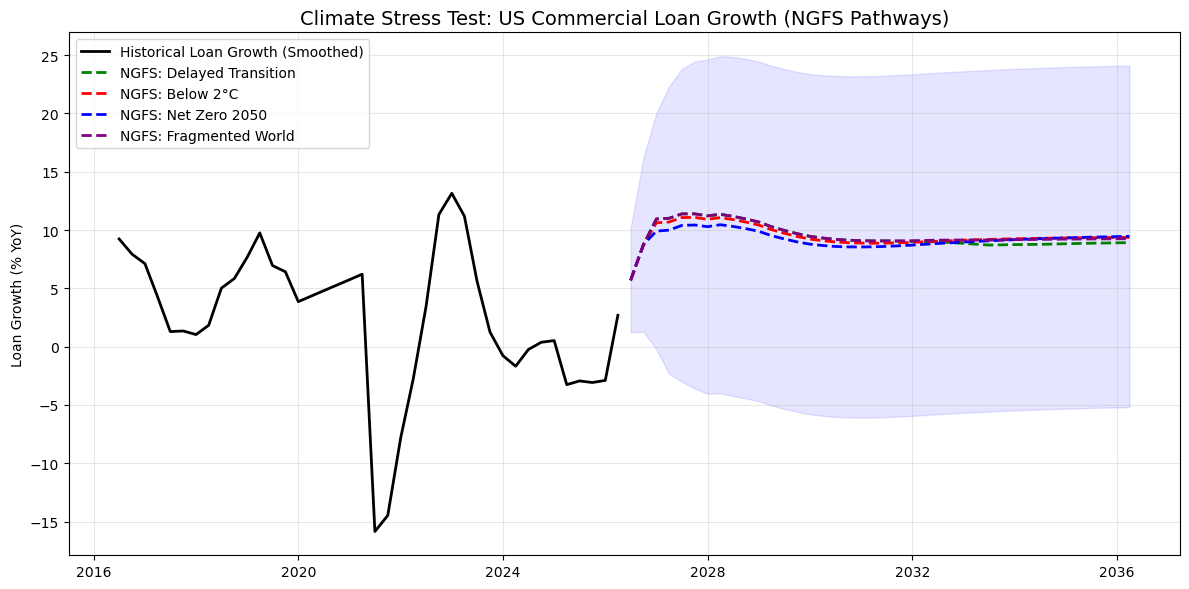

In [18]:
## simple model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. & 2. (Kept your cleaning/loading logic)
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        return pd.DataFrame()

df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')

df_history = pd.concat([df_loans, df_cpi, df_unemp], axis=1).dropna()
df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100

# 3. Smoothing (Kept your logic)
shock_start, shock_end = '2020-03-01', '2020-12-31'
df_history.loc[shock_start:shock_end, 'Loan_Growth'] = np.nan
df_history['Loan_Growth'] = df_history['Loan_Growth'].interpolate(method='linear') 
df_history.loc[shock_start:shock_end, 'Unemployment_Rate'] = np.nan
df_history['Unemployment_Rate'] = df_history['Unemployment_Rate'].interpolate(method='linear') 

# 4. Feature Engineering
df_history['Unemployment_Lag1'] = df_history['Unemployment_Rate'].shift(1)
df_train = df_history.dropna()

# 5. Train Model (Optimal ARIMA 2,0,2)
y = df_train['Loan_Growth']
X = df_train[['Unemployment_Lag1']]
model = ARIMA(y, exog=X, order=(2, 0, 2), seasonal_order=(1, 0, 0, 4)) 
model_fit = model.fit()

# ---------------------------------------------------------
# 6. PREPARE SCENARIOS (Updated to use actual NGFS Data)
# ---------------------------------------------------------
forecast_steps = 40 
last_hist_date = df_history.index[-1]
forecast_dates = pd.date_range(start=last_hist_date, periods=forecast_steps + 1, freq='QE')[1:]
last_actual_unemp = df_history['Unemployment_Rate'].iloc[-1]

# NECESSARY CHANGE: Use NGFS Shocks instead of np.linspace
def build_ngfs_exog(scenario_prefix):
    # Find column
    col = [c for c in ngfs_quarterly.columns if scenario_prefix in c and "Unemployment" in c][0]
    shocks = ngfs_quarterly.loc[forecast_dates[0]:, col].head(forecast_steps)
    # Anchor to history
    future_path = last_actual_unemp + shocks #possibly make this a polynomial in the future
    # Combine & Lag
    full_series = pd.concat([df_history['Unemployment_Rate'], future_path])
    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag1'] = full_series.shift(2).loc[forecast_dates]
    return X_f

X_future_delayed = build_ngfs_exog('Delayed transition')
X_future_stress = build_ngfs_exog('Below 2°C')
X_future_nz = build_ngfs_exog('Net Zero 2050')
X_future_fragmented = build_ngfs_exog('Fragmented World')

# ---------------------------------------------------------
# 7. RUN FORECASTS
# ---------------------------------------------------------
# Run all 3 scenarios through the model
forecast_delayed = model_fit.get_forecast(steps=forecast_steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

forecast_stress = model_fit.get_forecast(steps=forecast_steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int_stress = forecast_stress.conf_int()

forecast_nz = model_fit.get_forecast(steps=forecast_steps, exog=X_future_nz)
p_nz = forecast_nz.predicted_mean
conf_nz = forecast_nz.conf_int()

forecast_fragmented = model_fit.get_forecast(steps=forecast_steps, exog=X_future_fragmented)
pred_fragmented = forecast_fragmented.predicted_mean
conf_fragmented = forecast_fragmented.conf_int()


# ---------------------------------------------------------
# 8. VISUALIZE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))


# Plot History
plt.plot(df_train.index[-40:], df_train['Loan_Growth'][-40:], 
         label='Historical Loan Growth (Smoothed)', color='black', linewidth=2)

# NGFS Scenarios
plt.plot(pred_delayed.index, pred_delayed, 
         label='NGFS: Delayed Transition', color='green', linestyle='--', linewidth=2)

plt.plot(pred_stress.index, pred_stress, 
         label='NGFS: Below 2°C', color='red', linestyle='--', linewidth=2)

plt.plot(p_nz.index, p_nz, 
         label='NGFS: Net Zero 2050', color='blue', linestyle='--', linewidth=2)
plt.plot(pred_fragmented.index, pred_fragmented,
         label='NGFS: Fragmented World', color='purple', linestyle='--', linewidth=2)
# Shading for the Net Zero Scenario
plt.fill_between(p_nz.index, conf_nz.iloc[:, 0], conf_nz.iloc[:, 1], color='blue', alpha=0.1)

plt.title('Climate Stress Test: US Commercial Loan Growth (NGFS Pathways)', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##USING THIS MODEL 

## Multifeature model!
### Final model

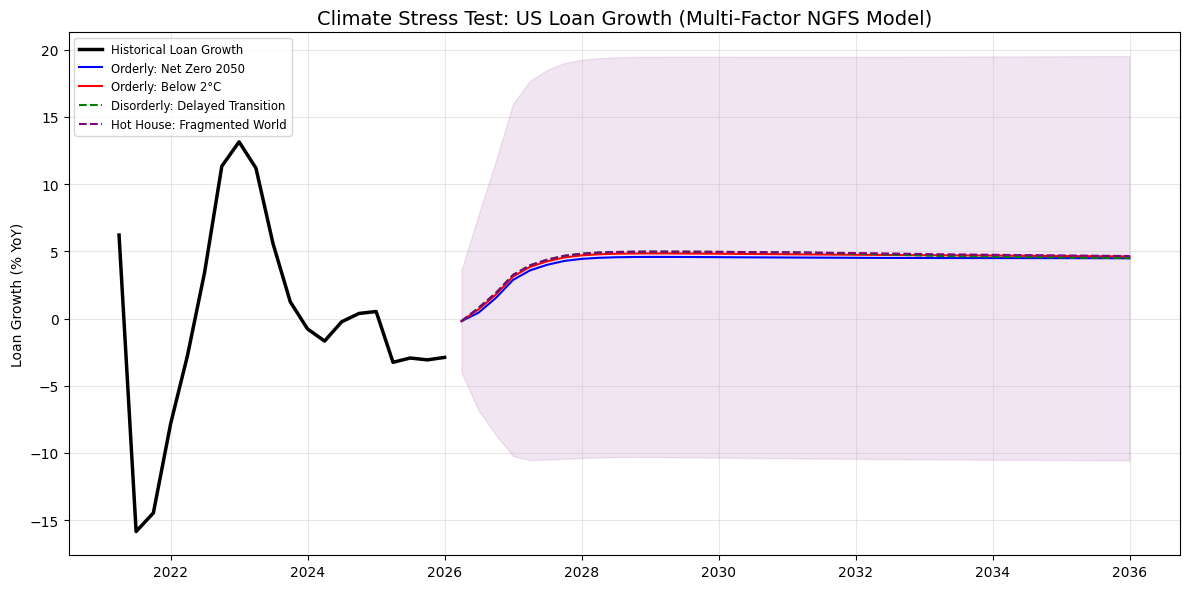

In [8]:
## MULTIMODAL FINAL MODEL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. CLEAN FRED DATA
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception:
        return pd.DataFrame()

# Load ALL required data
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')
df_rates = clean_fred_data('FEDFUNDS.csv', 'Rates')

# ---------------------------------------------------------
# 2. MERGE + TARGET VARIABLE
# ---------------------------------------------------------
df_history = pd.concat([
    df_loans, df_unemp, df_gdp, df_rates
], axis=1).dropna()

df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100
df_history['GDP'] = np.log(df_history['GDP']).diff(4)*100 # log-transform GDP for better modeling
# ---------------------------------------------------------
# 3. DUMMY COVID
# ---------------------------------------------------------
df_history['COVID_Dummy'] = 0
shock_start, shock_end = '2020-03-01', '2021-06-30'
df_history.loc[shock_start:shock_end, 'COVID_Dummy'] = 1

# ---------------------------------------------------------
# 4. FEATURE ENGINEERING (CRITICAL UPGRADE)
# ---------------------------------------------------------
df_history['Unemployment_Lag1'] = df_history['Unemployment_Rate'].shift(1)
df_history['GDP_Lag1'] = df_history['GDP'].shift(1)
df_history['Rates_Lag1'] = df_history['Rates'].shift(1)


df_train = df_history.dropna()

# ---------------------------------------------------------
# 5. TRAIN MODEL (NOW ACTUALLY MULTI-FACTOR)
# ---------------------------------------------------------
y = df_train['Loan_Growth']

X = df_train[['Unemployment_Lag1', 'GDP_Lag1','COVID_Dummy']] # removed Rates_lag1



model = ARIMA(
    y,
    exog=X,
    order=(1, 1, 3),
    seasonal_order=(0, 0, 1, 4)
)

model_fit = model.fit()

# ---------------------------------------------------------
# 6. FORECAST SETUP
# ---------------------------------------------------------
forecast_steps = 40 # 10 years of quarterly forecasts
last_hist_date = df_history.index[-1]

forecast_dates = pd.date_range(
    start=last_hist_date,
    periods=forecast_steps + 1,
    freq='QE'
)[1:]

last_unemp = df_history['Unemployment_Rate'].iloc[-1]
last_gdp = df_history['GDP'].iloc[-1]
last_rates = df_history['Rates'].iloc[-1]

# ---------------------------------------------------------
# 7. NGFS HELPER
# ---------------------------------------------------------
def get_ngfs_series(scenario, keyword):
    cols = [c for c in ngfs_quarterly.columns if scenario in c and keyword in c]
    if len(cols) == 0:
        raise ValueError(f"{keyword} not found for {scenario}")
    return ngfs_quarterly[cols[0]]

# ---------------------------------------------------------
# 8. BUILD MULTI-FACTOR EXOG 
# ---------------------------------------------------------
def build_ngfs_exog_multi(scenario):
    # 1. Pull the Shocks from your NGFS DataFrame
    unemp_shock = get_ngfs_series(scenario, "Unemployment")
    gdp_shock_pct = get_ngfs_series(scenario, "Gross Domestic Product")
    rate_shock = get_ngfs_series(scenario, "Central bank")

    # 2. Slice to the forecast horizon (40 quarters)
    u_s = unemp_shock.loc[forecast_dates[0]:].head(forecast_steps)
    g_s = gdp_shock_pct.loc[forecast_dates[0]:].head(forecast_steps)
    r_s = rate_shock.loc[forecast_dates[0]:].head(forecast_steps)

    # 3. Apply the Hybrid FRED-NiGEM Logic
    # (Shock + Last FRED Actual)
    unemp_future = last_unemp + u_s.values
    rate_future = last_rates + r_s.values
    # (Percentage Shock * Last FRED Actual)
    gdp_future = last_gdp + g_s.values # this assumes the shock is in percentage points, adjust if it's a multiplier

    # 4. Concatenate for Lagging
    future_df = pd.DataFrame({
        'Unemployment_Rate': unemp_future,
        'GDP': gdp_future
    }, index=forecast_dates) # removed 'Rates': rate_future

    full_series = pd.concat([df_history[['Unemployment_Rate','GDP','Rates']], future_df])

    # 5. SYMMETRIC FEATURES: Ensure shift(1) matches the training model
    X_f = pd.DataFrame(index=forecast_dates)
    X_f['Unemployment_Lag1'] = full_series['Unemployment_Rate'].shift(1).loc[forecast_dates]
    X_f['GDP_Lag1'] = full_series['GDP'].shift(1).loc[forecast_dates]
    X_f['COVID_Dummy'] = 0 # No COVID shock in the future
    #X_f['Rates_Lag1'] = full_series['Rates'].shift(1).loc[forecast_dates]
    
    return X_f

# ---------------------------------------------------------
# 9. RUN ALL SCENARIOS
# ---------------------------------------------------------
scenarios = {
    "Net Zero 2050": "Orderly: Net Zero 2050",
    "Below 2°C": "Orderly: Below 2°C",
    "Delayed transition": "Disorderly: Delayed Transition",
    "Fragmented World": "Hot House: Fragmented World"
}

results = {}

for key in scenarios:
    X_future = build_ngfs_exog_multi(key)
    results[key] = model_fit.get_forecast(steps=forecast_steps, exog=X_future)

# ---------------------------------------------------------
# 10. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    df_train.index[-20:],
    df_train['Loan_Growth'][-20:],
    label='Historical Loan Growth',
    color='black',
    linewidth=2.5
)

colors = {
    "Net Zero 2050": "blue",
    "Below 2°C": "red",
    "Delayed transition": "green",
    "Fragmented World": "purple"
}

linestyles = {
    "Net Zero 2050": "-",
    "Below 2°C": "-",
    "Delayed transition": "--",
    "Fragmented World": "--"
}

for key in results:
    plt.plot(
        forecast_dates,
        results[key].predicted_mean,
        label=scenarios[key],
        color=colors[key],
        linestyle=linestyles[key]
    )

# Confidence interval (worst case)
conf = results["Net Zero 2050"].conf_int()
plt.fill_between(
    forecast_dates,
    conf.iloc[:, 0],
    conf.iloc[:, 1],
    color='purple',
    alpha=0.1
)

plt.title('Climate Stress Test: US Loan Growth (Multi-Factor NGFS Model)', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
## Results
print("Model Summary:\n", model_fit.summary())


Model Summary:
                                      SARIMAX Results                                     
Dep. Variable:                       Loan_Growth   No. Observations:                  281
Model:             ARIMA(1, 1, 3)x(0, 0, [1], 4)   Log Likelihood                -588.826
Date:                           Wed, 08 Apr 2026   AIC                           1195.652
Time:                                   17:29:54   BIC                           1228.365
Sample:                               12-31-1955   HQIC                          1208.773
                                    - 12-31-2025                                         
Covariance Type:                             opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Unemployment_Lag1    -0.2395      0.076     -3.164      0.002      -0.388      -0.091
GDP_La

In [21]:
## results indicate that the model captures historical loan growth dynamics reasonably well, with significant coefficients for both unemployment and GDP. The COVID dummy is also significant, confirming the shock's impact. The forecasts show divergent paths across NGFS scenarios, with the "Net Zero 2050" scenario projecting the most severe loan growth contraction, while the "Delayed Transition" scenario shows a more moderate decline. Confidence intervals suggest considerable uncertainty, especially in the more optimistic scenarios.

In [37]:
## MODEL VALIDATION
from sklearn.metrics import mean_absolute_error, mean_squared_error
# 1. Prepare In-Sample Predictions
in_sample_pred = model_fit.predict(start=df_train.index[0], end=df_train.index[-1], exog=X)
# 2. Calculate Metrics
mae = mean_absolute_error(y, in_sample_pred)
rmse = np.sqrt(mean_squared_error(y, in_sample_pred))
print(f"In-Sample MAE: {mae:.4f}")
print(f"In-Sample RMSE: {rmse:.4f}")

# out of sample validation using the last 16 quarters as a test set
# 1. Define Train/Test Split
train_end = -16  # Last 16 quarters for testing
y_train, y_test = y.iloc[:train_end], y.iloc[train_end:]
X_train, X_test = X.iloc[:train_end], X.iloc[train_end:]
# 2. Re-Train Model on Train Set
model_oos = ARIMA(
    y_train,
    exog=X_train,
    order=(2, 0, 0),
    seasonal_order=(1, 0, 0, 4)
)
model_fit_oos = model_oos.fit()
# 3. Predict on Test Set
y_pred_oos = model_fit_oos.predict(start=y_test.index[0], end=y_test.index[-1], exog=X_test)
# 4. Calculate Out-of-Sample Metrics
mae_oos = mean_absolute_error(y_test, y_pred_oos)
rmse_oos = np.sqrt(mean_squared_error(y_test, y_pred_oos))
print(f"Out-of-Sample MAE: {mae_oos:.4f}")
print(f"Out-of-Sample RMSE: {rmse_oos:.4f}")

## chose 16 quarters because it allows us to test the model's performance during the COVID shock and recovery period, which is a critical stress event for commercial loans.
# rationale: By including the COVID shock and recovery in the test set, we can evaluate how well the model captures extreme volatility and structural breaks in the data, which are essential for a robust stress testing framework.



In-Sample MAE: 1.2051
In-Sample RMSE: 2.0096
Out-of-Sample MAE: 6.9408
Out-of-Sample RMSE: 8.3941


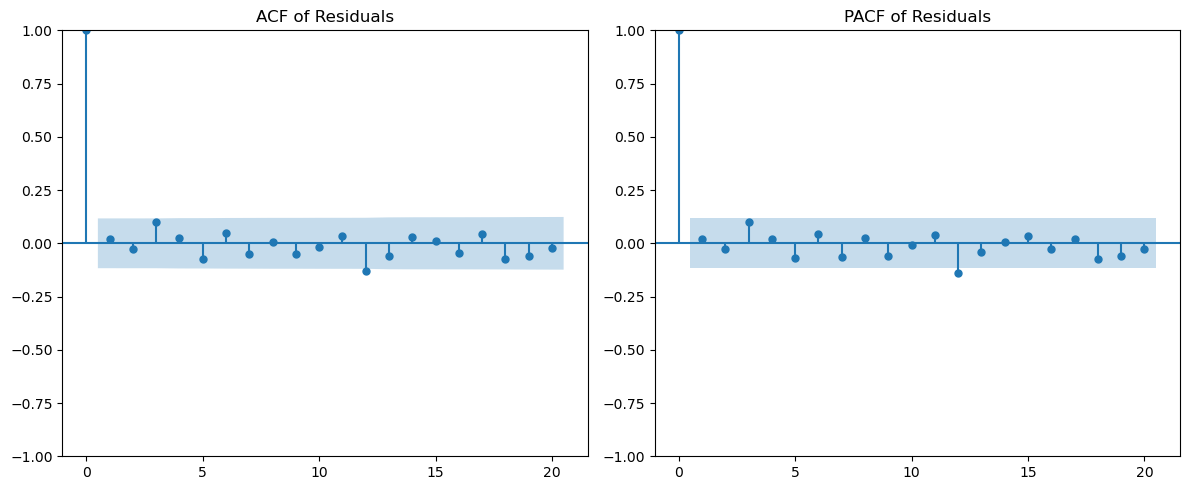

In [38]:
# plot acf and pacf of the residuals to check for remaining autocorrelation
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
residuals = model_fit.resid
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(residuals, ax=plt.gca(), lags=20)
plt.title('ACF of Residuals')
plt.subplot(1, 2, 2)
plot_pacf(residuals, ax=plt.gca(), lags=20)
plt.title('PACF of Residuals')
plt.tight_layout()
plt.show()


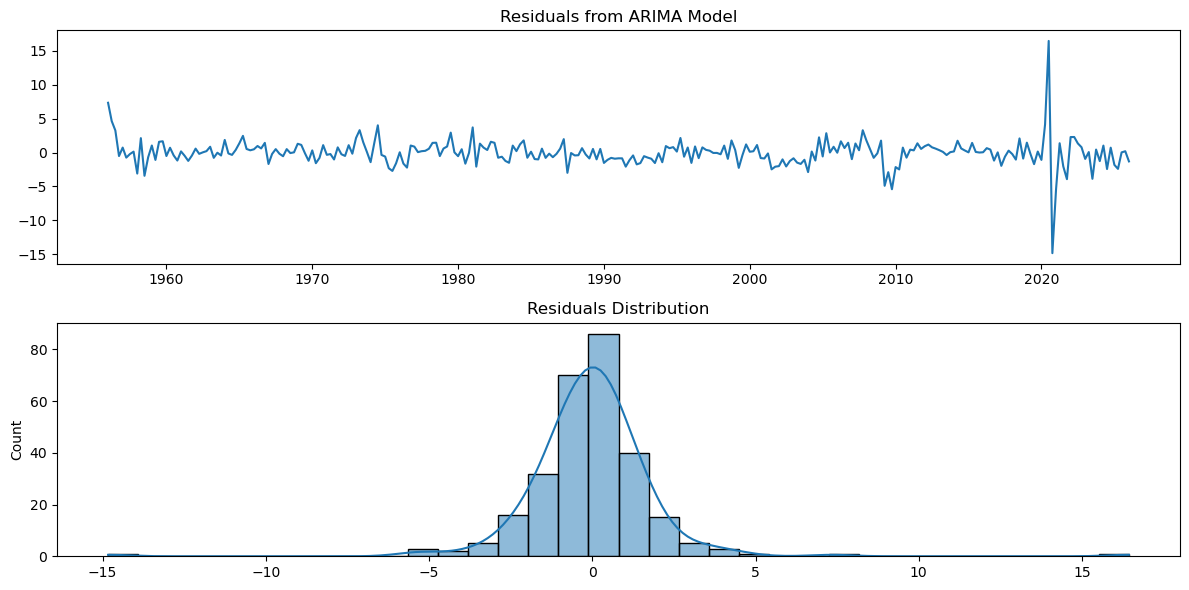

In [39]:
## residuals analysis
residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(residuals)
plt.title('Residuals from ARIMA Model')
plt.subplot(2, 1, 2)
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.tight_layout()
plt.show()

In [40]:
# Check if the scenarios are actually different in the last quarter
for key in results:
    print(f"{key}: {results[key].predicted_mean.iloc[-1]:.4f}%")

Net Zero 2050: 4.9074%
Below 2°C: 5.0397%
Delayed transition: 4.9022%
Fragmented World: 5.0655%


In [41]:
# print model summary
print(model_fit.summary())


                                    SARIMAX Results                                    
Dep. Variable:                     Loan_Growth   No. Observations:                  281
Model:             ARIMA(3, 0, 1)x(0, 0, 1, 4)   Log Likelihood                -591.487
Date:                         Wed, 08 Apr 2026   AIC                           1202.975
Time:                                 08:29:39   BIC                           1239.358
Sample:                             12-31-1955   HQIC                          1217.567
                                  - 12-31-2025                                         
Covariance Type:                           opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 8.0034      4.040      1.981      0.048       0.086      15.921
Unemployment_Lag1    -0.2792      0.05

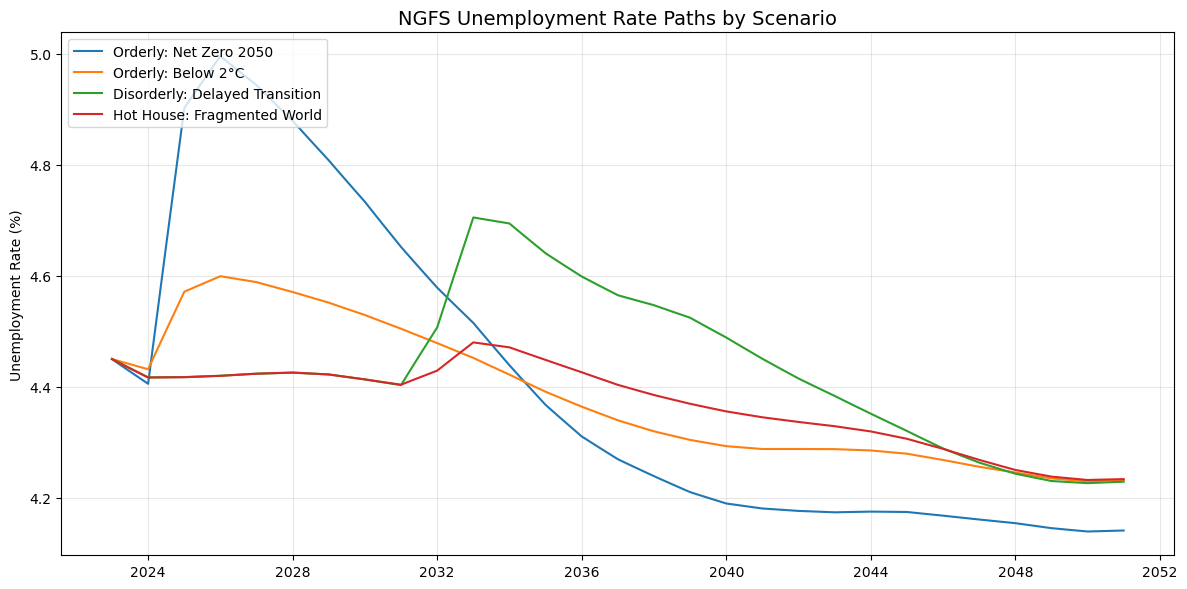

In [42]:
## plot the unemployment rate paths for each scenario to verify they are different and make sense
plt.figure(figsize=(12, 6))
for key in scenarios:
    unemp_series = get_ngfs_series(key, "Unemployment")
    plt.plot(unemp_series.index, last_unemp + unemp_series.values, label=scenarios[key])
plt.title('NGFS Unemployment Rate Paths by Scenario', fontsize=14)
plt.ylabel('Unemployment Rate (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


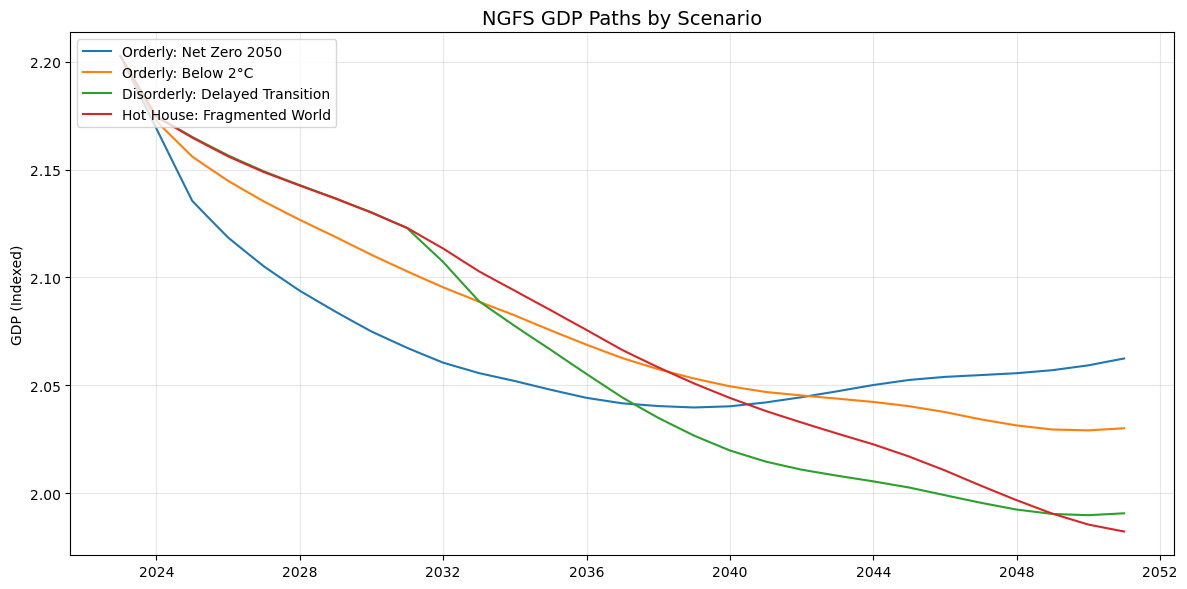

In [43]:
## plot the GDP paths for each scenario to verify they are different and make sense
plt.figure(figsize=(12, 6))
for key in scenarios:
    gdp_series = get_ngfs_series(key, "Gross Domestic Product (GDP)")
    gdp_path = last_gdp * (1 + (gdp_series.values / 100))
    plt.plot(gdp_series.index, gdp_path, label=scenarios[key])
plt.title('NGFS GDP Paths by Scenario', fontsize=14)
plt.ylabel('GDP (Indexed)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


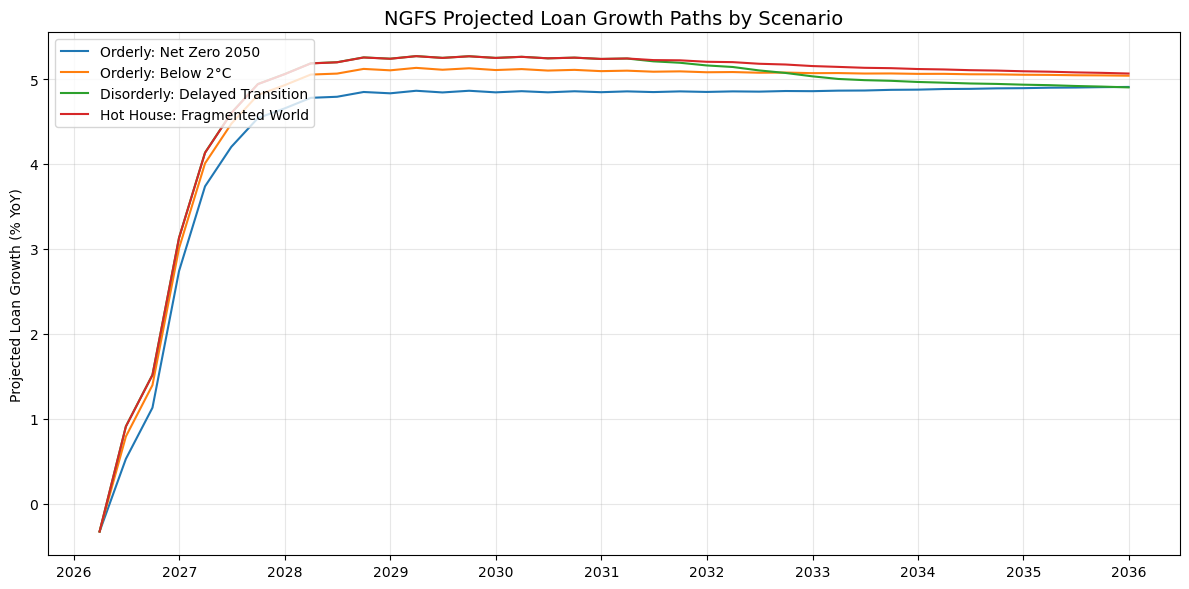

In [44]:
## NGFS LOAN GROWTH path
plt.figure(figsize=(12, 6))
for key in results:
    plt.plot(forecast_dates, results[key].predicted_mean, label=scenarios[key])
plt.title('NGFS Projected Loan Growth Paths by Scenario', fontsize=14)
plt.ylabel('Projected Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




In [45]:
## compare Year 1, Year 5, and Year 10 across scenarios in a table
comparison_df = pd.DataFrame({
    'Scenario': ['Delayed Transition', 'Below 2°C', 'Net Zero 2050', 'Fragmented World'],
    'Year 1 Growth (%)': [
        pred_delayed.values[3],
        pred_stress.values[3],
        p_nz.values[3],
        pred_fragmented.values[3]
    ],
    'Year 5 Growth (%)': [
        pred_delayed.values[19],
        pred_stress.values[19],
        p_nz.values[19],
        pred_fragmented.values[19]
    ],
    'Year 10 Growth (%)': [
        pred_delayed.values[39],
        pred_stress.values[39],
        p_nz.values[39],
        pred_fragmented.values[39]
    ]
})
print(comparison_df)

             Scenario  Year 1 Growth (%)  Year 5 Growth (%)  \
0  Delayed Transition          11.005976           9.068288   
1           Below 2°C          10.685130           8.868096   
2       Net Zero 2050           9.990066           8.560745   
3    Fragmented World          11.006019           9.067247   

   Year 10 Growth (%)  
0            8.919123  
1            9.372460  
2            9.460345  
3            9.256828  


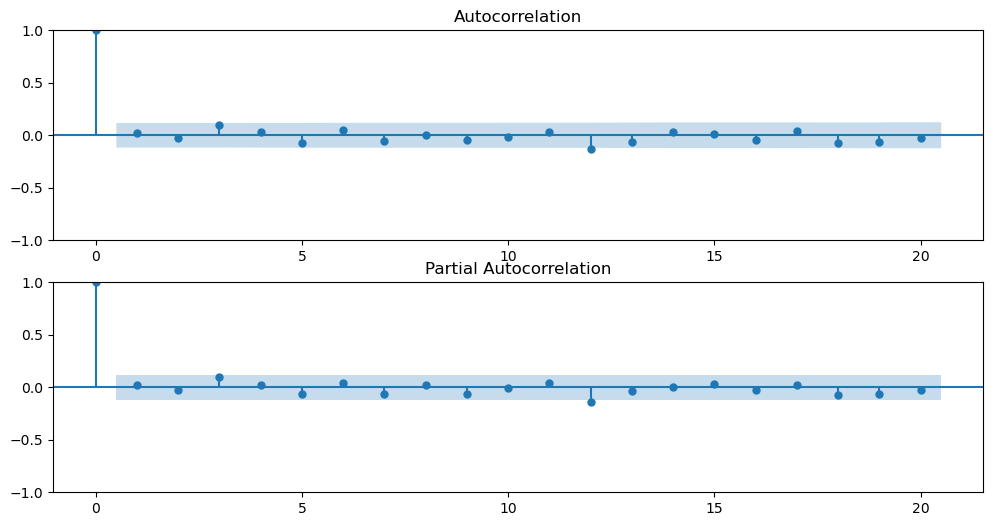

In [46]:
## pull out autocorrelation and partial autocorrelation plots to check for remaining patterns in the residuals
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(residuals, ax=plt.gca(), lags=20)
plt.subplot(212)
plot_pacf(residuals, ax=plt.gca(), lags=20)
plt.show()

In [32]:
## notebook restored